In [71]:
from interpret.glassbox import ExplainableBoostingClassifier
from interpret import show
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np
from sklearn.metrics import roc_auc_score, roc_curve, auc, classification_report, confusion_matrix


df = pd.read_csv('../data/processed/NY_SLI_ATTOM_NEW.csv')
df_numeric_data = df.drop(columns=[
    'Lead Gooseneck, Pigtail or Connector Currently Present',
    'Current Public Side SL Material',
    'Was Public SL Material Ever Previously Lead',
    'Public SL Material Verification Method',
    'Customer SL Material',
    'Lead Solder Present',
    'Customer SL Size',
    'SL Category', 
    'Note', 
    'Current SL Material Category', 'Lead Connector Present Category',
    'Current Public Side SL Material Category',
    'Was Public SL Material Ever Previously Lead Category',
    'Public SL Size Numeric', 
    'attomID',
    'Service Line Locality',
    'Street Address',
    'State',
    'Public SL Size',
    'Customer SL Material Verification Method',
    'POU or POE Treatment Present',
    'Building Type',
    'prop_class',
    'size_ind',
    'Public SL Installation Year',
    'Public SL Material Verification Method Category',
    'Public SL Size Category',
    'Customer SL Material Category',
])
print(df_numeric_data.columns)
def safe_float(x):
    try:
        return float(x)
    except (ValueError, TypeError):
        return False
def safe_install_year(x) -> bool:
    return safe_float(x) > 1500 and safe_float(x) < 2025

def condition_numeric(x):
    if x == 'NaN' or type(x) == float: # only if nan
        return 0
    if x == 'FAIR':
        return 1
    if x == 'AVERAGE':
        return 2
    if x == 'GOOD':
        return 3
    if x == 'EXCELLENT':
        return 4
df_numeric_data[['Longitude', 'Latitude']] = (
    df_numeric_data['Location']
    .str.extract(r'POINT\s*\(\s*([-.\d]+)\s+([-.\d]+)\s*\)')
    .astype(float)
)
df_numeric_data = df_numeric_data.drop(columns='Location')
df_numeric_data = df_numeric_data[df_numeric_data['living_size'] < 10_000]
df_numeric_data['construction_condition'] = df_numeric_data['construction_condition'].apply(condition_numeric)
df_numeric_data['Public SL Installation or Replacement Date'] = df_numeric_data.apply(lambda row: row['year_built'] if not safe_install_year(row['Public SL Installation or Replacement Date']) else float(row['Public SL Installation or Replacement Date']), axis=1 )
for col in df_numeric_data:
    if col != 'SL Category Cleaned':
        df_numeric_data[col] = df_numeric_data[col].apply(float)

len(df_numeric_data[df_numeric_data['SL Category Cleaned'] == 'Lead'])

Index(['Zip Code', 'Public SL Installation or Replacement Date',
       'Customer SL Installation or Replacement Date', 'Location',
       'SL Category Cleaned', 'lot_size2', 'year_built', 'living_size', 'beds',
       'baths_total', 'levels', 'market_total_value',
       'construction_condition'],
      dtype='object')


318

In [72]:
y = df_numeric_data['SL Category Cleaned']

print(len(df_numeric_data.columns))
df_numeric_data = df_numeric_data.drop(columns='SL Category Cleaned')
X = df_numeric_data.to_numpy()
print(len(X[0]))
# X = np.hstack([X[:, 0:2], X[:, 3:]])
print(len(X[0]))

y = y[~np.isnan(X).any(axis=1)]
X = X[~np.isnan(X).any(axis=1)]

X = pd.DataFrame(
    data=X,
    columns=df_numeric_data.columns,
)

le = LabelEncoder()
y_encoded = le.fit_transform(y)
# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# Standardize features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

pca = PCA(n_components=10)
X_train_reduced = pca.fit_transform(X_train_scaled)
X_test_reduced = pca.transform(X_test_scaled)
X

14
13
13


,Zip Code,Public SL Installation or Replacement Date,Customer SL Installation or Replacement Date,lot_size2,year_built,living_size,beds,baths_total,levels,market_total_value,construction_condition,Longitude,Latitude
0,14901.0,1976.0,1976.0,7020.0,1900.0,2890.0,4.0,3.0,2.0,100000.0,2.0,-76.81887,42.09131
1,14904.0,1958.0,1958.0,6250.0,1925.0,1336.0,3.0,1.0,2.0,83600.0,2.0,-76.79192,42.08219
2,14901.0,1965.0,1965.0,23680.0,1987.0,900.0,0.0,0.0,1.0,296700.0,0.0,-76.79436,42.09401
3,14901.0,1968.0,1972.0,14768.0,1920.0,1457.0,3.0,2.0,2.0,94300.0,2.0,-76.82159,42.10316
4,14904.0,1962.0,1962.0,4200.0,1900.0,1600.0,4.0,2.0,2.0,32800.0,1.0,-76.79828,42.07872
...,...,...,...,...,...,...,...,...,...,...,...,...,...
958,13088.0,1945.0,1945.0,8184.0,1945.0,1837.0,3.0,1.0,2.0,185185.0,2.0,-76.21314,43.10989
959,10977.0,1995.0,1970.0,10454.0,1995.0,1332.0,4.0,2.0,1.0,15400.0,2.0,-74.05628,41.09958
960,10977.0,1968.0,1970.0,23087.0,1968.0,2328.0,4.0,2.0,1.0,74700.0,2.0,-74.04092,41.07490
961,10977.0,1988.0,1970.0,35284.0,1988.0,3038.0,4.0,2.0,2.0,84100.0,2.0,-74.05022,41.07291


In [73]:
ebm = ExplainableBoostingClassifier(feature_names=X.columns.tolist(),)
ebm.fit(X_train_scaled, y_train)

,feature_names,"['Zip Code', 'Public SL Installation or Replacement Date', ...]"
,feature_types,None
,max_bins,1024
,max_interaction_bins,64
,interactions,'3x'
,exclude,None
,validation_size,0.15
,outer_bags,14
,inner_bags,0
,learning_rate,0.015
,greedy_ratio,10.0


In [74]:
ebm_global = ebm.explain_global()
show(ebm_global)

<!-- http://127.0.0.1:7001/131329061110272/ -->

In [75]:
y_pred = ebm.predict(X_test_scaled)
y_pred_proba = ebm.predict_proba(X_test_scaled)

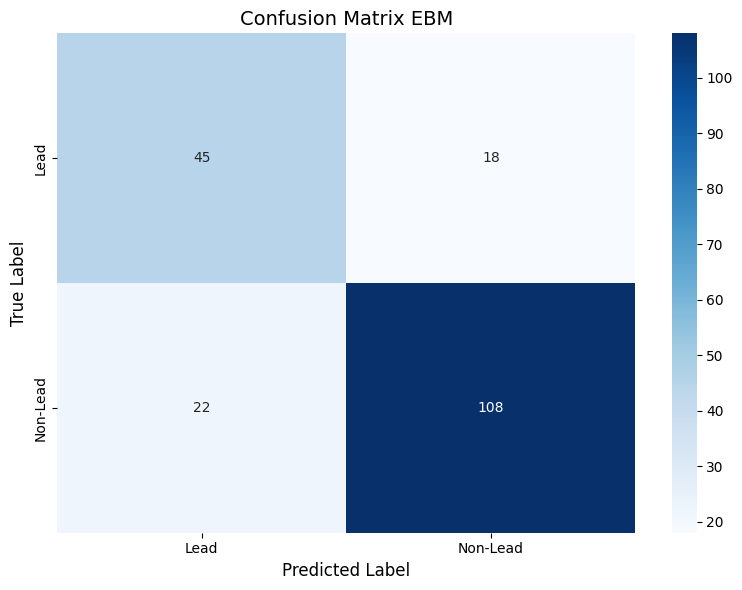

              precision    recall  f1-score   support

           0       0.67      0.71      0.69        63
           1       0.86      0.83      0.84       130

    accuracy                           0.79       193
   macro avg       0.76      0.77      0.77       193
weighted avg       0.80      0.79      0.79       193



0.8363858363858364

In [76]:
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
           xticklabels=le.classes_, yticklabels=le.classes_)
plt.title(f'Confusion Matrix EBM', fontsize=14)
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.savefig('../results/knn_confusion_matrix.png')
plt.show()
print(classification_report(y_test, y_pred))

roc_auc_score(y_test, y_pred_proba[:, 1])
